In [ ]:
!pip install tensorflow=='2.15' --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorstore 0.1.67 requires ml-dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.


## Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Conv2D, BatchNormalization, ReLU, Add,
                                     GlobalAveragePooling2D, Dense, Input,
                                     Concatenate, Layer, Maximum, Dropout, Multiply)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import ImageFile

In [ ]:
import math

## Model Parameters

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 16
N_EPOCHS = 100
LR = 1e-3

VALUE_DT = 0.2
THETA=0.7

PATH_DIR = ''

ImageFile.LOAD_TRUNCATED_IMAGES = True

## Model Functions

In [ ]:
class RGBtoHSV(Layer):
    def __init__(self, **kwargs):
        super(RGBtoHSV, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.image.rgb_to_hsv(inputs)

    def get_config(self):
        config = super(RGBtoHSV, self).get_config()
        return config

class RGBtoYCbCr(Layer):
    def __init__(self, **kwargs):
        super(RGBtoYCbCr, self).__init__(**kwargs)

    def call(self, inputs):

        rgb_to_ycbcr_kernel = tf.constant([[0.299, 0.587, 0.114],
                                           [-0.1687, -0.3313, 0.5],
                                           [0.5, -0.4187, -0.0813]])
        offset = tf.constant([0, 128/255, 128/255], dtype=tf.float32)
        ycbcr = tf.tensordot(inputs, rgb_to_ycbcr_kernel, axes=[[3], [1]]) + offset

        return ycbcr

    def get_config(self):
        config = super(RGBtoYCbCr, self).get_config()
        return config

In [ ]:
class FuzzyPooling(Layer):
    def __init__(self, pool_size=(2, 2), strides=None, padding='VALID', fuzzy_k=2, **kwargs):
        super(FuzzyPooling, self).__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides if strides is not None else pool_size
        self.padding = padding.upper()
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        patches = tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.pool_size[0], self.pool_size[1], 1],
            strides=[1, self.strides[0], self.strides[1], 1],
            rates=[1, 1, 1, 1],
            padding=self.padding
        )

        batch_size = tf.shape(inputs)[0]
        new_height = tf.shape(patches)[1]
        new_width = tf.shape(patches)[2]
        channels = inputs.shape[-1]
        patch_dim = self.pool_size[0] * self.pool_size[1]

        patches = tf.reshape(patches, [batch_size, new_height, new_width, channels, patch_dim])


        max_vals = tf.reduce_max(patches, axis=-1, keepdims=True)
        min_vals = tf.reduce_min(patches, axis=-1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(patches - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(patches * membership, axis=-1)
        denominator = tf.reduce_sum(membership, axis=-1) + 1e-6
        fuzzy_pool = numerator / denominator

        return fuzzy_pool

    def compute_output_shape(self, input_shape):

        if self.padding == 'VALID':
            out_height = (input_shape[1] - self.pool_size[0]) // self.strides[0] + 1
            out_width = (input_shape[2] - self.pool_size[1]) // self.strides[1] + 1
        elif self.padding == 'SAME':
            out_height = (input_shape[1] + self.strides[0] - 1) // self.strides[0]
            out_width = (input_shape[2] + self.strides[1] - 1) // self.strides[1]
        else:
            raise ValueError(f"Invalid padding type: {self.padding}")

        return (input_shape[0], out_height, out_width, input_shape[3])

    def get_config(self):

        config = super(FuzzyPooling, self).get_config()
        config.update({
            'pool_size': self.pool_size,
            'strides': self.strides,
            'padding': self.padding,
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
class GlobalFuzzyPooling2D(Layer):
    def __init__(self, fuzzy_k=2, **kwargs):
        super(GlobalFuzzyPooling2D, self).__init__(**kwargs)
        self.fuzzy_k = fuzzy_k

    def call(self, inputs):

        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        channels = inputs.shape[3]

        inputs_flat = tf.reshape(inputs, [batch_size, height * width, channels])

        max_vals = tf.reduce_max(inputs_flat, axis=1, keepdims=True)
        min_vals = tf.reduce_min(inputs_flat, axis=1, keepdims=True)
        denom = max_vals - min_vals + 1e-6

        membership = 1 - tf.abs(inputs_flat - max_vals) / denom
        membership = tf.pow(membership, self.fuzzy_k)

        numerator = tf.reduce_sum(inputs_flat * membership, axis=1)
        denominator = tf.reduce_sum(membership, axis=1) + 1e-6
        fuzzy_global_pool = numerator / denominator

        return fuzzy_global_pool

    def compute_output_shape(self, input_shape):

        return (input_shape[0], input_shape[3])

    def get_config(self):

        config = super(GlobalFuzzyPooling2D, self).get_config()
        config.update({
            'fuzzy_k': self.fuzzy_k,
        })
        return config

In [ ]:
KI_VS = tf.keras.initializers.variance_scaling(scale=2.0)

In [ ]:
class Conv2d_cd(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, strides=1,
                 padding='SAME', theta=0.7, use_bias=False,
                 kernel_initializer=tf.keras.initializers.variance_scaling(scale=2.0),
                 name='conv2d_cd',
                 **kwargs):
        super(Conv2d_cd, self).__init__(name=name, **kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides
        self.padding = padding.upper() if padding in ['same', 'valid'] else padding
        self.theta = theta
        self.use_bias = use_bias
        self.kernel_initializer = kernel_initializer

    def build(self, input_shape):
        input_channels = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=[self.kernel_size, self.kernel_size, input_channels, self.filters],
            initializer=self.kernel_initializer,
            trainable=True
        )
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.filters,),
                initializer='zeros',
                trainable=True
            )

    def call(self, inputs):
        out_normal = tf.nn.conv2d(inputs, self.kernel, strides=[1, self.strides, self.strides, 1], padding=self.padding)

        if math.fabs(self.theta - 0.0) < 1e-8:
            if self.use_bias:
                out_normal = tf.nn.bias_add(out_normal, self.bias)
            return out_normal

        kernel_diff = tf.reduce_sum(self.kernel, axis=0, keepdims=True)
        kernel_diff = tf.reduce_sum(kernel_diff, axis=1, keepdims=True)
        kernel_diff = tf.tile(kernel_diff, [self.kernel_size, self.kernel_size, 1, 1])

        out_diff = tf.nn.conv2d(inputs, kernel_diff, strides=[1, self.strides, self.strides, 1], padding=self.padding)
        output = out_normal - self.theta * out_diff

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

    def get_config(self):
        config = super(Conv2d_cd, self).get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'strides': self.strides,
            'padding': self.padding,
            'theta': self.theta,
            'use_bias': self.use_bias,
            'kernel_initializer': tf.keras.initializers.serialize(self.kernel_initializer),
        })
        return config

In [ ]:
np.random.seed(42)

In [ ]:
def residual_block(x, filters, stride=1, theta=THETA):
    shortcut = x
    x = Conv2d_cd(filters=filters, kernel_size=3, strides=stride, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2d_cd(filters=filters, kernel_size=3, strides=1, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2d_cd(filters=filters, kernel_size=1, strides=stride, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(shortcut)
        shortcut = Dropout(VALUE_DT)(shortcut, training=True)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

In [ ]:
def backbone_resnet18(x, theta=THETA):
    x = Conv2d_cd(filters=64, kernel_size=7, strides=2, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = FuzzyPooling(pool_size=(3, 3), strides=(2, 2), padding='SAME')(x)

    x = residual_block(x, 64, stride=1, theta=theta)
    x = residual_block(x, 64, stride=1, theta=theta)

    x = residual_block(x, 128, stride=2, theta=theta)
    x = residual_block(x, 128, stride=1, theta=theta)

    x = residual_block(x, 256, stride=2, theta=theta)
    x = residual_block(x, 256, stride=1, theta=theta)

    x = residual_block(x, 512, stride=2, theta=theta)
    x = residual_block(x, 512, stride=1, theta=theta)

    return x

In [ ]:
def phd_resnet18(input_shape=INPUT_SHAPE, theta=THETA):
    inputs = Input(shape=input_shape)

    hsv_image = RGBtoHSV()(inputs)

    ycbcr_image = RGBtoYCbCr()(inputs)

    concatenated_inputs = Concatenate()([inputs, hsv_image, ycbcr_image])

    paper_branch = backbone_resnet18(concatenated_inputs)
    replay_branch = backbone_resnet18(concatenated_inputs)
    mask_branch = backbone_resnet18(concatenated_inputs)

    liveness_branch = backbone_resnet18(concatenated_inputs)

    x = GlobalFuzzyPooling2D()(paper_branch)

    paper_output = Dense(2, activation='softmax', name='paper_output')(x)

    x = GlobalFuzzyPooling2D()(replay_branch)
    replay_output = Dense(2, activation='softmax', name='replay_output')(x)

    x = GlobalFuzzyPooling2D()(mask_branch)
    mask_output = Dense(2, activation='softmax', name='mask_output')(x)

    x = GlobalFuzzyPooling2D()(liveness_branch)
    liveness_output = Dense(2, activation='softmax', name='liveness_output')(x)

    concatenated_spoofs = Multiply()([paper_branch, replay_branch, mask_branch])

    x = Conv2d_cd(filters=512, kernel_size=3, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(concatenated_spoofs)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    concatenated_liveness = Concatenate()([x, liveness_branch])

    x = Conv2d_cd(filters=512, kernel_size=3, padding='same', theta=theta, name='conv2d_cd'+str(np.random.randint(1000000)))(concatenated_liveness)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalFuzzyPooling2D()(x)
    liveness_final_output = Dense(2, activation='softmax', name='liveness_final_output')(x)

    model = tf.keras.models.Model(inputs, [paper_output, replay_output, mask_output, liveness_output, liveness_final_output])
    return model


## Build Model

In [ ]:
model = phd_resnet18()

optimizer_model = Adam(learning_rate=LR)
model.compile(optimizer=optimizer_model, loss='categorical_crossentropy',
              metrics='accuracy',
              )

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer VarianceScaling is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

In [ ]:
model.save('model.keras')

In [ ]:
dot_img_file = '/tmp/model_1.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)

Output hidden; open in https://colab.research.google.com to view.

## Load Data

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/MSU_MFSD/face/msu_mfsd_faces.zip" .
!unzip -qq msu_mfsd_faces.zip

In [ ]:
np.random.seed(2024)
df = pd.read_csv('/content/gdrive/MyDrive/DATABASES/MSU_MFSD/face/msu_mfsd_faces_intradataset_min.csv', index_col=False)
df.sample(3)

In [ ]:
def create_list(value, classes):
    cat_list = np.zeros(len(classes))
    cat_list[classes.index(value)] = 1
    return cat_list

In [ ]:
df['distortion_type'] = 'original'
df['full_path_iqa'] = 'faces/'+df.data_type+'/'+df.label+'/'+df.scene+'/'+df.frame

df['paper_label'] = df.scene.apply(lambda x: x.split('_')[-2]).apply(lambda x: 0 if x.lower() in 'video' else 1).apply(create_list, args=([0, 1],))
df['mask_label'] = df.scene.apply(lambda x: 1).apply(create_list, args=([0, 1],))
df['replay_label'] = df.scene.apply(lambda x: x.split('_')[-2]).apply(lambda x: 0 if x.lower() in 'photo' else 1).apply(create_list, args=([0, 1],))


df['liveness_label'] = df.label.apply(lambda x: 0 if x=='attack' else 1).apply(create_list, args=([0, 1],))
df['liveness_final_label'] = df.liveness_label


df.sample(3)

In [ ]:
df.shape

In [ ]:
train = df[df.data_type=='train']
val = df[df.data_type=='test']

TOTAL_TRAIN = train.shape[0]
TOTAL_VAL = val.shape[0]

print(f'Total Training Samples: {TOTAL_TRAIN}')
print(f'Total Valid Samples: {TOTAL_VAL}')

In [ ]:
train

## Prepare Data

In [ ]:
train_datagen = ImageDataGenerator(
    brightness_range=[0.4, 1.4],
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE
)

In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    val,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Train Model

In [ ]:
earlystop_callback = EarlyStopping(patience=10)

learning_rate_reduction_callback = ReduceLROnPlateau(monitor='val_loss',
                                            patience=5,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=1e-8)

mcp_save_callback = ModelCheckpoint(
    '/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_5/saved_model_msuminintra_phd5_vL{val_loss}.keras',
    save_best_only=True, monitor='val_loss', mode='min', verbose=1)

callbacks_list = [earlystop_callback, learning_rate_reduction_callback, mcp_save_callback]

In [ ]:
history = model.fit(
    train_generator,
    epochs=N_EPOCHS,
    validation_data=val_generator,
    validation_steps=val.shape[0]//BATCH_SIZE,
    steps_per_epoch=train.shape[0]//BATCH_SIZE,
    callbacks=callbacks_list
)

Epoch 1/100
531/531 [==============================] - ETA: 0s - loss: 1.2515 - paper_output_loss: 0.3149 - replay_output_loss: 3.1582e-04 - mask_output_loss: 0.2383 - liveness_output_loss: 0.3785 - liveness_final_output_loss: 0.3195 - paper_output_accuracy: 0.8894 - replay_output_accuracy: 0.9999 - mask_output_accuracy: 0.9162 - liveness_output_accuracy: 0.8617 - liveness_final_output_accuracy: 0.8709
Epoch 1: val_loss improved from inf to 26.39924, saving model to /content/gdrive/MyDrive/Universidad/PhD_Models/saved_model/phd_model_5/saved_model_msuminintra_phd5_vL26.399240493774414.keras
531/531 [==============================] - 370s 595ms/step - loss: 1.2515 - paper_output_loss: 0.3149 - replay_output_loss: 3.1582e-04 - mask_output_loss: 0.2383 - liveness_output_loss: 0.3785 - liveness_final_output_loss: 0.3195 - paper_output_accuracy: 0.8894 - replay_output_accuracy: 0.9999 - mask_output_accuracy: 0.9162 - liveness_output_accuracy: 0.8617 - liveness_final_output_accuracy: 0.8709 

## Save Model

In [ ]:
model.save('[PhD_5][CeAS_RDmin][Intra-Test]ResNet-18-CDC-MCD-FP.keras')
!cp "[PhD_5][CeAS_RDmin][Intra-Test]ResNet-18-CDC-MCD-FP.keras" "/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_5/"

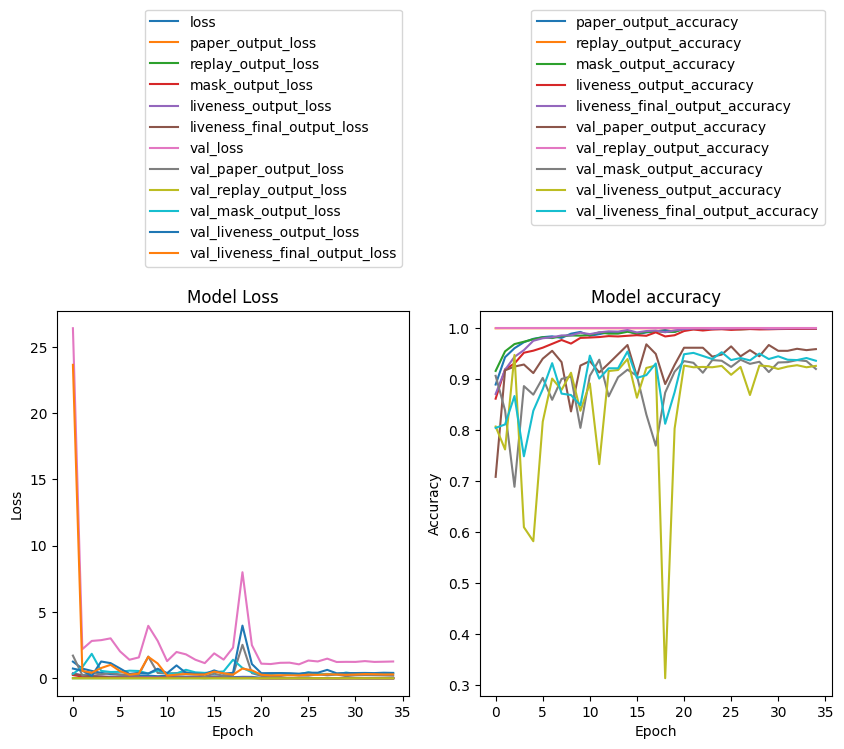

In [ ]:
loss_metrics = [x for x in history.history.keys() if 'loss' in x]
acc_metrics = [x for x in history.history.keys() if 'accuracy' in x]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for metric in loss_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loss_metrics, bbox_to_anchor=(1.00, 1.80))

plt.subplot(1, 2, 2)
for metric in acc_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(acc_metrics, bbox_to_anchor=(1.00, 1.80))

plt.show()

## Predict

In [ ]:
import tqdm
np.random.seed(42)
tf.random.set_seed(42)
no_times=25
for i in tqdm.tqdm(range(no_times), total=no_times):
   predict = np.array(model.predict(val_generator, verbose=1))[:,:,1:]


   if i==0:
       predict_test_array = predict.copy()
   else:
       predict_test_array = np.concatenate([predict_test_array, predict], axis=-1)

  0%|          | 0/25 [00:00<?, ?it/s]

94/94 [==============================] - 19s 168ms/step


  4%|▍         | 1/25 [00:19<07:51, 19.66s/it]

94/94 [==============================] - 15s 160ms/step


  8%|▊         | 2/25 [00:34<06:33, 17.11s/it]

...

 92%|█████████▏| 23/25 [05:54<00:30, 15.21s/it]

94/94 [==============================] - 15s 159ms/step


 96%|█████████▌| 24/25 [06:09<00:15, 15.22s/it]

94/94 [==============================] - 15s 159ms/step


100%|██████████| 25/25 [06:24<00:00, 15.39s/it]


In [ ]:
val['paper_pred'] = predict_test_array[0].tolist()
val['mask_pred'] = predict_test_array[1].tolist()
val['replay_pred'] = predict_test_array[2].tolist()
val['liveness_pred'] = predict_test_array[3].tolist()
val['liveness_final_pred'] = predict_test_array[4].tolist()
val.to_csv(f'/content/gdrive/MyDrive/PhD_Models/PhDresults/PhD5_protIntra_trMSU_valMSU_min.csv', index=False)
val.head(3)

<ipython-input-37-1203888959c4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['paper_pred'] = predict_test_array[0].tolist()
<ipython-input-37-1203888959c4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['mask_pred'] = predict_test_array[1].tolist()
<ipython-input-37-1203888959c4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

,frame,scene,client,label,data_type,full_path,distortion_type,full_path_iqa,paper_label,mask_label,replay_label,liveness_label,liveness_final_label,paper_pred,mask_pred,replay_pred,liveness_pred,liveness_final_pred
8500,frame_183.jpg,attack_client035_android_SD_iphone_video_scene01,client035,attack,test,faces/test/attack/attack_client035_android_SD_...,original,faces/test/attack/attack_client035_android_SD_...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[2.342684553291452e-11, 1.6042538131255668e-10...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.4708445572608753e-09, 3.230759659800242e-09...","[2.304636042009707e-15, 2.4732777607091964e-15..."
8501,frame_201.jpg,real_client051_laptop_SD_scene01,client051,real,test,faces/test/real/real_client051_laptop_SD_scene...,original,faces/test/real/real_client051_laptop_SD_scene...,"[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[0.0, 1.0]","[0.9999977350234985, 0.9999982118606567, 0.999...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.29017651081085205, 0.11498890817165375, 0.1...","[0.9998229146003723, 0.9998867511749268, 0.999...","[0.9192032217979431, 0.9184978604316711, 0.942..."
8502,frame_59.jpg,attack_client033_laptop_SD_ipad_video_scene01,client033,attack,test,faces/test/attack/attack_client033_laptop_SD_i...,original,faces/test/attack/attack_client033_laptop_SD_i...,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[0.018273508176207542, 0.001471495721489191, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.9883611798286438, 0.9999953508377075, 0.999...","[1.9961909856647253e-05, 1.1853625437652227e-0...","[4.90879756398499e-07, 7.474927343764648e-08, ..."


END